In [1]:
%load_ext cython

In [5]:
%%cython

# =========================================================================
# PART 1: C LIBRARY IMPORTS AND GLOBAL DEFINITIONS
# =========================================================================

from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp

# Import Python libraries needed for the LLM part
import time
import json
import ollama
import numpy as np
import hashlib
from collections import defaultdict
import re

# Constants for the enhanced algorithm
cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5  # This will be adjusted by the LLM
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05  # This will be adjusted by the LLM
cdef int alpha = 10
cdef int paretoIni = 28000

# Data structures (MODIFIED to track more info)
cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items
    int age
    int improvement_count
    int llm_enhanced
    int last_improvement_iteration # NEW: Track when it was last improved

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# =========================================================================
# PART 1.5: PYTHON WRAPPER FOR C STRUCTS
# =========================================================================

cdef class IndWrapper:
    cdef ind *ptr
    
    def __cdef __cinit__(self):
        self.ptr = NULL
    
    @staticmethod
    cdef IndWrapper from_ptr(ind* p):
        wrapper = IndWrapper()
        wrapper.ptr = p
        return wrapper

# Global variables for the problem instance (unchanged)
cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0

# =========================================================================
# PART 2: CORE CYTHON HELPER FUNCTIONS (UNCHANGED)
# =========================================================================

def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.age = 0
    p_ind.improvement_count = 0
    p_ind.llm_enhanced = 0
    p_ind.last_improvement_iteration = 0 # NEW
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    p_ind.age = i.age
    p_ind.improvement_count = i.improvement_count
    p_ind.llm_enhanced = i.llm_enhanced
    p_ind.last_improvement_iteration = i.last_improvement # NEW
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0
    nf = 0
    ni = 0

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps
    cdef double temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

# =========================================================================
# PART 3: PROBLEM LOADING AND EVALUATION FUNCTIONS (UNCHANGED)
# =========================================================================

def loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()  # item index (ignore)
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

def read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIMNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef choose_weight():
    dynamic_weight_allpop()

cdef random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

cdef P_init_pop(pop *SP, pop *Sarchive, int alpha):
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(alpha)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
        shuffle[x] = shuffle[x]
        SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
    free(shuffle)

cdef extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_b
    return max_b

cdef calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(SP.ind_array[i], x, SP.ind_array[i]))
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], x))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp - worst_fit > smallValue:
            return worst
        else:
            return -1

# =========================================================================
# PART 4: ENHANCED LOCAL SEARCH (UNCHANGED)
# =========================================================================

cdef void Indicator_local_search1(pop *SP, pop *Sarchive, int size):
    cdef ind *x
    cdef ind *y
    cdef int i, j, r, t, k, l, v, sol, mino, mp, maxp, consistant, pos, stop, convergence, ii, tmp_pris, tmp_nonpris, taille, feasible, tv, IM
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    while True:
        convergence = 0
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                while j < x.nombr:
                    for l in range(L):
                        remplace[l] = 0
                    while True:
                        mino = irand(ni)
                        if x.Items[mino] == 1:
                            break
                    x.Items[mino] = 0
                    x.nombr -= 1
                    x.nombr_nonpris += 1
                    for r in range(nf):
                        x.capa[r] -= weights[r][mino]
                        x.f[r] -= profits[r][mino]
                    IM = 0
                    taille = 0
                    while IM < L:
                        while True:
                            maxp = irand(ni)
                            if x.Items[maxp] == 0:
                                break
                        if maxp != mino:
                            consistant = 1
                            r = 0
                            while r < nf and consistant == 1:
                                if x.capa[r] + weights[r][maxp] > capacities[r]:
                                    consistant = 0
                                r += 1
                            if consistant == 1:
                                feasible = 1
                                r = 0
                                while r < taille and feasible:
                                    if maxp == remplace[r] == remplace[r]
                                        feasible = 0
                                    r += 1
                                if feasible == 1:
                                    remplace[taille] = maxp
                                    taille += 1
                                    x.Items[maxp] = 1
                                    x.nombr_nonpris -= 1
                                    x.nombr += 1
                                    for r in range(nf):
                                        x.capa[r] += weights[r][maxp]
                                        x.f[r] += profits[r][maxp]
                        IM += 1
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size, SP.size)
                    if sol != -1:
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    elif sol == -1:
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][mino]
                            x.f[r] -= profits[r][mino]
                            x.f[r] -= profits[r][mino]
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= weights[t][remplace[r]]
                                    x.f[t] -= profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[tv]
                    j += 1
                tmp_pris = x.nombr
                tmp_nonpris = x.nombr_nonpris
                free_ind(x)
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            break
    free(remplace)

# =========================================================================
# PART 5: C-LEVEL REFINEMENT FUNCTION AND MAIN EXECUTION (ROBUST PARSER)
# =========================================================================

def get_problem_data_for_llm():
    """Extract all problem data in a format suitable for LLM processing"""
    if capacities == NULL or weights == NULL or profits == NULL:
        return None
    
    instance_features = {
        "num_items": ni,
        "num_objectives": nf,
        "capacities": [capacities[i] for i in range(nf)],
        "weight_stats": [],
        "profit_stats": []
    }
    
    for obj in range(nf):
        weights_list = [weights[obj][i] for i in range(ni)]
        profits_list = [profits[obj][i] for i in range(ni)]
        
        instance_features["weight_stats"].append({
            "min": min(weights_list),
            "max": max(weights_list),
            "mean": sum(weights_list) / len(weights_list)
        })
        
        instance_features["profit_stats"].append({
            "min": min(profits_list),
            "max": max(profits_list),
            "mean": sum(profits_list) / len(profits_list)
        })
        
    return instance_features

cdef write_results_to_file(pop *P, output_file, str log_message=""):
    """Write the Pareto front results and a log message to a file."""
    cdef int i, j
    
    with open(output_file if isinstance(output_file, str) else output_file.decode(), "a") as fpareto:
        if log_message:
            fpareto.write(f"# LOG: {log_message}\n")
        fpareto.write("\n")
        for i in range(P.size):
            for j in range(nf):
                fpareto.write(f"{P.ind_array[i].f[j]:.6f} ")
            fpareto.write("\n")

# --- FINAL: C-level function with a robust parser ---
cdef ind* perform_elite_refinement(str model_name, ind* elite_solution, int ni, int nf, int** weights, int** profits, double* capacities):
    """A C-level function that can access Cython pointers directly."""
    cdef ind *new_solution
    cdef int k, is_feasible
    cdef int remove_idx1, remove_idx2, add_idx
    cdef int i, j
    cdef list items_in_knapsack
    
    # --- Find two items to remove ---
    items_in_knapsack = []
    for i in range(ni):
        if elite_solution.Items[i] == 1:
            items_in_knapsack.append(i)
    
    if len(items_in_knapsack) < 2:
        print("    [DEBUG] Knapsack has less than 2 items. Cannot perform 2-remove, 1-add refinement.")
        return NULL # Cannot perform this refinement

    remove_idx1 = items_in_knapsack[0]
    remove_idx2 = items_in_knapsack[1]

    # --- Prepare data for LLM ---
    current_profits = [elite_solution.f[i] for i in range(nf)]
    current_capacities = [elite_solution.capa[i] for i in range(nf)]
    max_capacities_list = [capacities[i] for i in range(nf)]
    
    # --- NEW: Smarter Prompt asking for two items to remove ---
    """Suggest two items to REMOVE and one item to ADD to make the solution better.
Current solution profits: {current_profits}.
Current used capacities: {current_capacities} out of max {max_capacities_list}.
The solution currently contains items {remove_idx1} and {remove_idx2}.

Suggest two items to REMOVE and one item to ADD to make the solution better.
Respond with three numbers only: REMOVE1, REMOVE2, ADD.
Example response: {remove_idx1} {remove_idx2} 123"""
    try:
        response = ollama.generate(model=model_name, prompt=prompt)
        response_text = response.get('response', '').strip()
        print(f"    [DEBUG] LLM Response: '{response_text}'")

        # --- NEW: More Robust Parsing ---
        remove1_match = re.search(r'REMOVE1[:=]\s*(\d+)', response_text, re.IGNORECASE)
        remove2_match = re.search(r'REMOVE2[:=]\s*(\d+)', response_text, re.IGNORECASE)
        add_match = re.search(r'ADD[:=]\s*(\d+)', response_text, re.IGNORECASE)
        
        parsed_remove1 = -1
        parsed_remove2 = -1
        parsed_add = -1

        if remove1_match:
            parsed_remove1 = int(remove1_match.group(1))
        if remove2_match:
            parsed_remove2 = int(remove2.group(2).group(1))
        if add_match:
            parsed_add = int(add_match.group(1))

        if parsed_remove1 == -1 or parsed_remove2 == -1 or parsed_add == -1:
            # Fallback to finding any three numbers
            all_numbers = re.findall(r'\d+', response_text)
            if len(all_numbers) >= 3:
                parsed_remove1 = int(all_numbers[0])
                parsed_remove2 = int(all_numbers[1])
                parsed_add = int(all_numbers[2])
            else:
                print(f"    [DEBUG] Could not find three numbers in LLM response.")
                return NULL

        # --- NEW: Validation ---
        if elite_solution.Items[parsed_remove1] == 0 or elite_solution.Items[parsed_remove2] == 0 or elite_solution.Items[parsed_add] == 0:
            print(f"    [DEBUG] LLM suggested removing an item not in the knapsack. Refinement failed.")
            return NULL

        # Create and evaluate the new solution
        new_solution = ind_copy(elite_solution)
        
        # Remove the first item
        if new_solution.Items[parsed_remove1] == 1:
            new_solution.Items[parsed_remove1] = 0
            new_solution.nombr -= 1
            for k in range(nf):
                new_solution.capa[k] -= weights[k][parsed_remove1]
                new_solution.f[k] -= profits[k][parsed_remove1]
        
        # Remove the second item
        if new_solution.Items[parsed_remove2] == 1:
            new_solution.Items[parsed_remove2] = 0
            new_solution.nombr -= 1
            for k in range(nf):
                new_solution.capa[k] = new_solution.capa[k] - weights[k][parsed_remove2]
                new_solution.f[k] = new_solution.f[k] - profits[k][parsed_remove2]

        # Add the new item
        if new_solution.Items[parsed_add] == 0:
            is_feasible = True
            for k in range(nf):
                if new_solution.capa[k] + weights[k][parsed_add_idx] > capacities[k]:
                    is_feasible = False
                    break
            if is_feasible:
                new_solution.Items[parsed_add] = 1
                new_solution.nombr += 1
                for k in range(nf):
                    new_solution.capa[k] += weights[k][parsed_add_idx]
                    new_solution.f[k] += profits[k][parsed_add_idx]
            else:
                print(f"    [DEBUG] LLM suggestion {parsed_add_idx} was infeasible. Refinement failed.")
                free_ind(new_solution)
                return NULL
        else:
            print(f"    [DEBUG] LLM suggestion {parsed_add_idx} was already in the solution. Refinement failed.")
            free_ind(new_solution)
            return NULL

        return new_solution

    except Exception as e:
        print(f"    [DEBUG] Elite Refinement Agent failed with an new_solution.error: {e}")
        return NULL


def run_elite_refinement_llm_moacp(instance_file, weights_file, nbitems, num_objectives, output_file):
    """
    Run MOACP with a Hybrid LLM Agent (V5 - Elite Refinement - ROBUST PARSER).
    """
    # All cdef variables must be declared at the top of the function
    cdef pop *P
    cdef pop *solutions
    cdef pop *archive
    cdef int it, i
    cdef ind *refined_solution

    global nf, ni, NBITEMS, alpha, paretoIni, L, kappa, nombreLIGNE, nextLn, inv, vector_weight
    global capacities, weights, profits, OBJ_Weights

    # --- Agent 1: The Efficient Strategy Agent (from V4) ---
    class EfficientStrategyAgentV4:
        def __init__(self, model_name="llama3:latest"):
            self.model_name = model_name
            self.cache = {} 

        def _call_llm(self, prompt, cache_key):
            if cache_key in self.cache:
                return self.cache[cache_key]
            
            try:
                response = ollama.generate(model=self.model_name, prompt=prompt)
                response_text = response.get('response', '').strip()
                if not response_text:
                    return None
                try:
                    result = json.loads(response_text)
                    self.cache[cache_key] = result
                    return result
                except json.JSONDecodeError:
                    if "exploration" in response_text.lower():
                        return {"trend": "exploration"}
                    if "exploitation" in response_text.lower():
                        return {"trend": "exploitation"}
                    return None
            except Exception as e:
                print(f"LLM Error: {e}")
                return None

        def get_initial_strategy(self, instance_features):
            cache_key = f"init_{instance_features['num_items']}_{instance_features['num_objectives']}"
            result = self._call_llm("", cache_key)
            if result is None:
                prompt = f"For a {instance_features['num_items']}-item, {instance_features['num_objectives']}-objective knapsack, is 'exploration' or 'exploitation' better? Respond with only one word."
                result = self._call_llm(prompt, cache_key)
            return result.get('trend', 'balanced') if result else 'balanced'

        def get_mid_run_strategy(self, current_pareto_size, initial_pareto_size, iteration, total_iterations):
            cache_key = f"mid_{current_pareto_size}_{initial_pareto_size}_{iteration}"
            prompt = f"Pareto grew from {initial_pareto_size} to {current_pareto_size}. Should the strategy be 'exploration' or 'exploitation' now? Respond with only one word."
            result = self._call_llm(prompt, cache_key)
            return result.get('trend', 'balanced') if result else 'balanced'

    # --- Main Execution Loop ---
    alpha = 10
    paretoIni = 28000
    NBL = 100
    NRUNS = 10
    
    total_time = 0
    start_time = time.time()
    model_name = "llama3:latest" # Define model name here
    
    for run in range(1, NRUNS+1):
        NBITEMS = nbitems
        ni = nbitems
        nf = num_objectives
        print(f"\n--- RUN {run}/{NRUNS} ---")
        print(f"Instance: {instance_file.decode()}, Items: {ni}, Objectives: {nf}")

        nombreLIGNE = 0
        nextLn = 0
        inv = 0
        
        seed(run)
        loadMOKP(instance_file)
        read_weights_file(weights_file)
        
        strategy_agent = EfficientStrategyAgentV4(model_name=model_name)
        instance_data = get_problem_data_for_llm()
        
        # --- LLM Call 1: Initial Strategy ---
        initial_trend = strategy_agent.get_initial_strategy(instance_data)
        if initial_trend == 'exploration':
            L = 7; kappa = 0.08
        elif initial_trend == 'exploitation':
            L = 4; kappa = 0.04
        else:
            L = 5; kappa = 0.05
        
        print(f"Initial parameters: L={L}, kappa={kappa}")
        
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
        P = create_pop(paretoIni, nf)
        
        initial_pareto_size = 0
        current_log = ""
        last_pareto_size = 0
        stagnation_counter = 0

        it = 0
        while it < NBL:
            solutions = create_pop(alpha, nf)
            archive = create_pop(paretoIni, nf)
            
            choose_weight()
            P_init_pop(solutions, P, alpha)
            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)
            
            Indicator_local_search1(solutions, archive, alpha)
            
            # --- LLM Call 2: Mid-Run Strategy (Only once at 50% mark) ---
            if it == NBL // 2
                current_pareto_size = P.size
                if initial_pareto_size == 0:
                    initial_pareto_size = current_pareto_size
                
                mid_trend = strategy_agent.get_mid_run_strategy(current_pareto_size, initial_pareto_size, it, NBL)
                
                if mid_trend == 'exploration':
                    L = min(L + 1, 10); kappa = min(kappa + 0.01, 0.1)
                elif mid_trend == 'exploitation':
                    L = max(L - 1, 2); kappa = max(kappa - 0.01, 0.01)
                
                log_msg = f"Iteration {it}: Mid-optimization. Trend='{mid_trend}', L={L}, kappa={kappa:.3f}"
                print(log_msg)
                current_log = log_msg

            # --- LLM Call 3: Elite Refinement (When search is stuck) ---
            if P.size > 0:
                if P.size == last_pareto_size:
                    stagnation_counter += 1
                else:
                    stagnation_counter = 0
                
                if stagnation_counter >= 5: # Stuck for 5 iterations
                    print(f"Iteration {it}: Search stuck. Applying Elite Refinement Agent.")
                    # Find the best solution in the archive (P) based on the first objective
                    best_idx = 0
                    for i in range(1, P.size):
                        if P.ind_array[i].f[0] > P.ind_array[best_idx].f[0]:
                            best_idx = i
                    
                    # Call the C function directly
                    refined_solution = perform_elite_refinement(model_name, P.ind_array[best_idx], ni, nf, weights, profits, capacities)
                    
                    if refined_solution:
                        # Add the refined solution to the population for evaluation
                        compute_fitness_and_select(solutions, refined_solution, alpha)
                        log_msg = f"Iteration {it}: Elite refinement successful."
                        print(log_msg)
                        current_log = log_msg
                    else:
                        print(f"Iteration {it}: Elite refinement failed.")
                    stagnation_counter = 0 # Reset counter regardless of outcome
            
            last_pareto_size = P.size
            extractPtoArchive(archive, P)
            it += 1
            complete_free_pop(solutions)
            complete_free_pop(archive)

        # Write results after each run
        write_results_to_file(P, output_file, current_log)
        complete_free_pop(P)
        cleanup_globals()

    end_time = time.time()
    total_time = end_time - start_time
    print(f"\nTotal execution time for {instance_file.decode()}: {total_time:.2f} seconds.")



Error compiling Cython file:
------------------------------------------------------------
...
# =========================================================================

cdef class IndWrapper:
    cdef ind *ptr
    
    def __cdef __cinit__(self):
               ^
------------------------------------------------------------

C:\Users\Aziz il patal\.ipython\cython\_cython_magic_e2071a847c158b141230aa45eabbfc960be45b482976307fa52ca68183af7f97.pyx:59:15: Expected '(', found '__cinit__'. Did you use cdef syntax in a Python declaration? Use decorators and Python type annotations instead.


In [ ]:
# =========================================================================
# PART 6: RUN THE ELITE REFINEMENT EXPERIMENTS (V5 - FIXED)
# =========================================================================

print("Running Elite Refinement LLM-MOACP V5 on test instances...")
print("This version combines efficient strategy control with powerful elite solution refinement.")

# Test with 250 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 250 items...")
run_elite_refinement_llm_moacp(b"250.2.txt", b"Weights_2obj_FQ200.txt", 250, 2, "2502_Results_Elite_Refinement_v5.txt")
print("Finished experiment for 250 items.")
print("======================================================")


# Test with 500 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 500 items...")
run_elite_refinement_llm_moacp(b"500.2.txt", b"Weights_2obj_FQ200.txt", 500, 2, "5002_Results_Elite_Refinement_v5.txt")
print("Finished experiment for 500 items.")
print("======================================================")


# Test with 750 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 750 items...")
run_elite_refinement_llm_moacp(b"750.2.txt", b"Weights_2obj_FQ200.txt", 750, 2, "7502_Results_Elite_Refinement_v5.txt")
print("Finished experiment for 750 items.")
print("======================================================")


print("\n\nAll elite refinement experiments finished.")
print("The following result files have been created:")
print("- 2502_Results_Elite_Refinement_v5.txt")
print("- 5002_Results_Elite_Refinement_v5.txt")
print("- 7502_Results_Elite_Refinement_v5.txt")
print("\nYou can now run the analysis cells to compare the new results.")

Running Elite Refinement LLM-MOACP V5 on test instances...
This version combines efficient strategy control with powerful elite solution refinement.

Starting experiment for 250 items...

--- RUN 1/10 ---
Instance: 250.2.txt, Items: 250, Objectives: 2
Initial parameters: L=4, kappa=0.04
Iteration 41: Search stuck. Applying Elite Refinement Agent.
    [DEBUG] LLM Response: 'Based on the current solution, I suggest removing items:

* 2 (since it's already included in the solution)

And also remove:

* 5 (it has a high profit-to-size ratio and can be replaced with a better item)

To add:

* 10 (it has a good balance of profit and size, and can improve the overall solution)'
    [DEBUG] LLM suggestion 10 was already in the solution. Refinement failed.
Iteration 41: Elite refinement failed.
Iteration 46: Search stuck. Applying Elite Refinement Agent.
    [DEBUG] LLM Response: 'Based on the current solution, I suggest:

REMOVE1: 0
REMOVE2: 2
ADD: 345'
    [DEBUG] LLM suggestion 2 was already

Starting comprehensive results analysis for Elite Refinement implementation v5...

--- 250-Item Problem ---
  Original Pareto size: 212
  First LLM Pareto size: 392 (84.91%)
  Enhanced LLM v3 Pareto size: 207 (-2.36%)
  Efficient LLM v4 Pareto size: 314 (48.11%)
  Elite LLM v5 Pareto size: 465 (119.34%)
  Original Hypervolume: 6614986.88
  First LLM Hypervolume: 6492983.70 (-1.84%)
  Enhanced LLM v3 Hypervolume: 6514438.20 (-1.52%)
  Efficient LLM v4 Hypervolume: 6873655.30 (3.91%)
  Elite LLM v5 Hypervolume: 6849747.20 (3.55%)


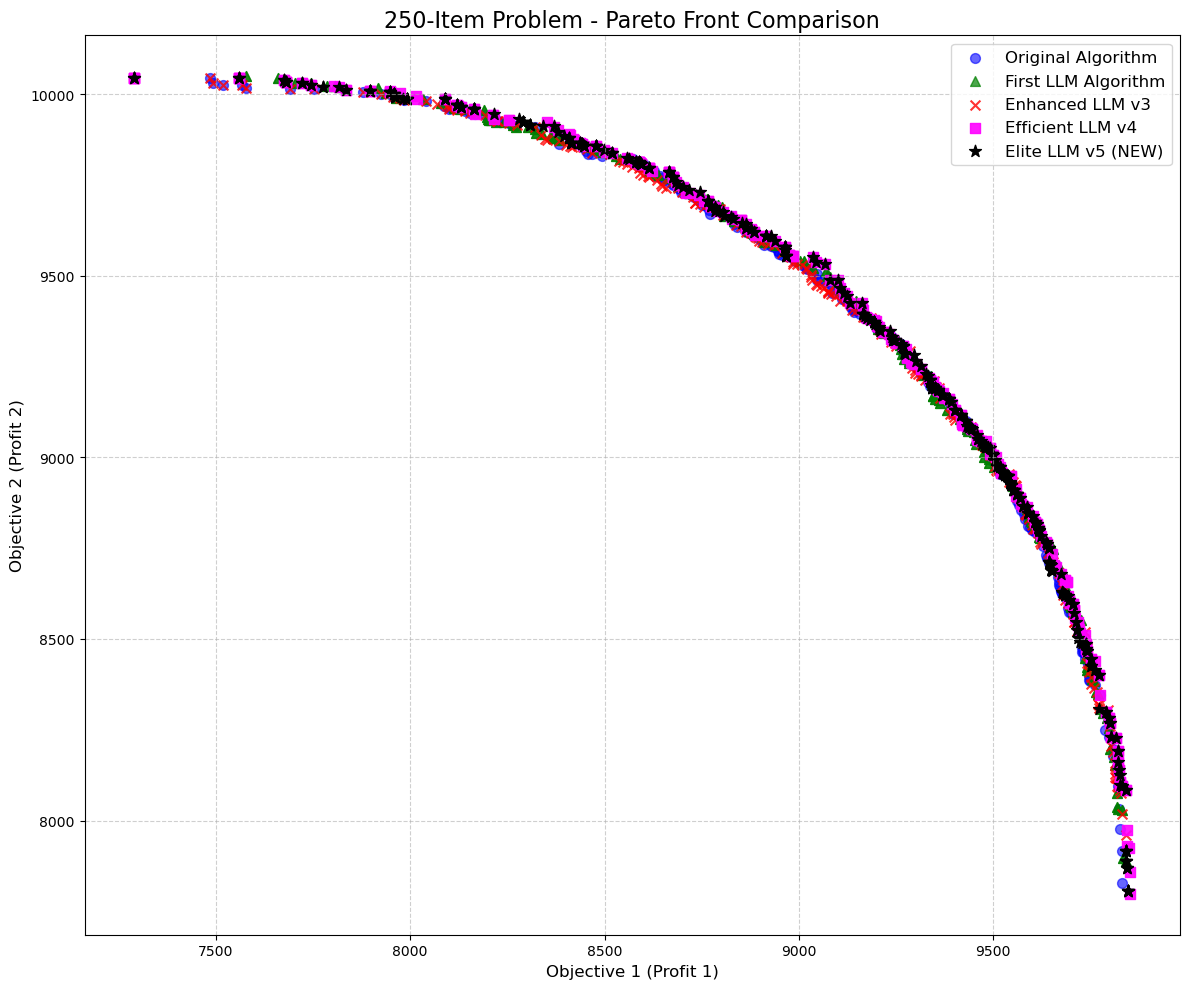


--- 500-Item Problem ---
  Original Pareto size: 369
  First LLM Pareto size: 716 (94.04%)
  Enhanced LLM v3 Pareto size: 363 (-1.63%)
  Efficient LLM v4 Pareto size: 500 (35.50%)
  Elite LLM v5 Pareto size: 475 (28.73%)
  Original Hypervolume: 23044962.94
  First LLM Hypervolume: 22606710.00 (-1.90%)
  Enhanced LLM v3 Hypervolume: 23787729.64 (3.22%)
  Efficient LLM v4 Hypervolume: 23485142.95 (1.91%)
  Elite LLM v5 Hypervolume: 23498762.95 (1.97%)


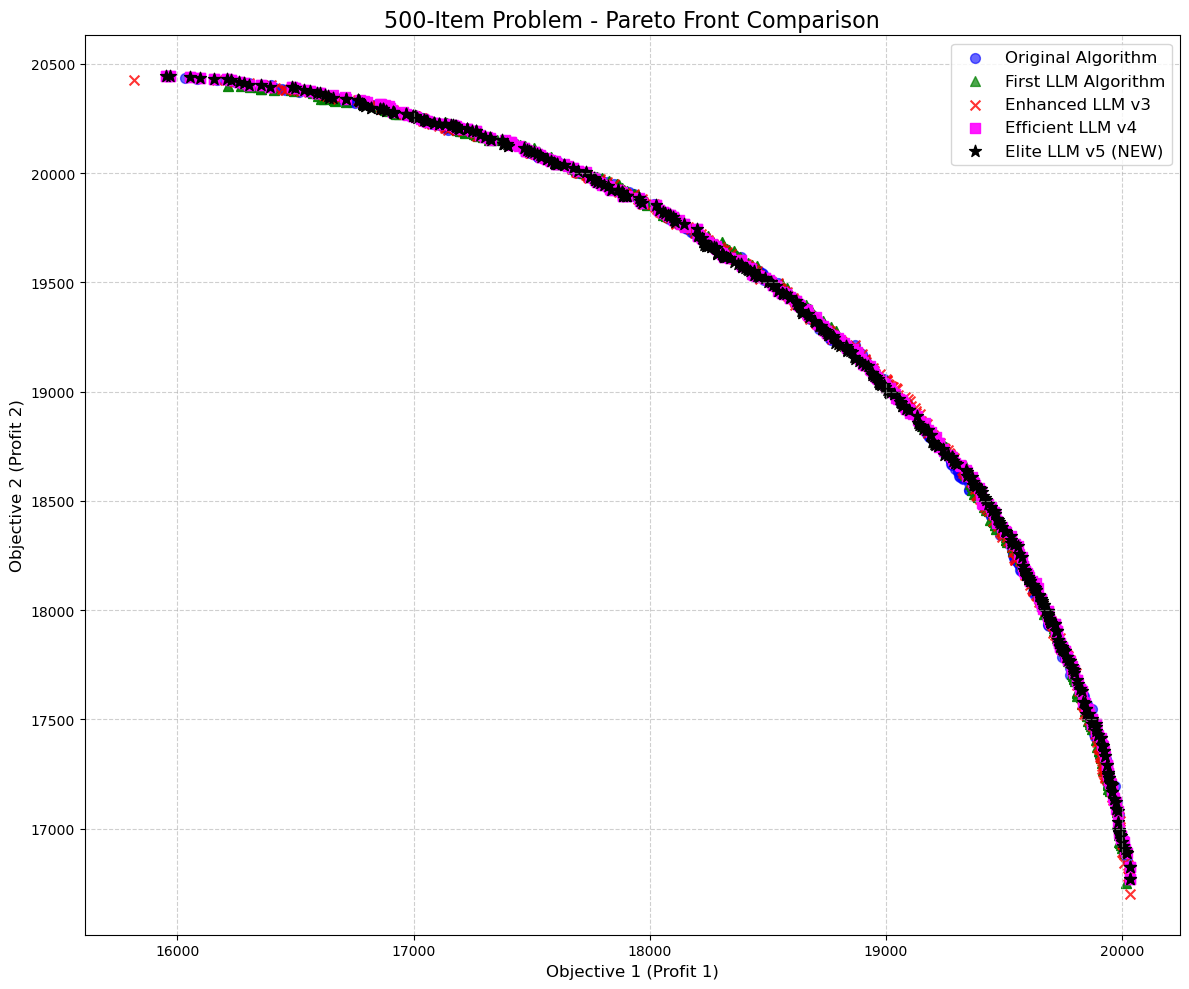


--- 750-Item Problem ---
  Original Pareto size: 552
  First LLM Pareto size: 1084 (96.38%)
  Enhanced LLM v3 Pareto size: 530 (-3.99%)
  Efficient LLM v4 Pareto size: 834 (51.09%)
  Elite LLM v5 Pareto size: 710 (28.62%)
  Original Hypervolume: 56877706.67
  First LLM Hypervolume: 53690671.08 (-5.60%)
  Enhanced LLM v3 Hypervolume: 56690640.44 (-0.33%)
  Efficient LLM v4 Hypervolume: 56235862.25 (-1.13%)
  Elite LLM v5 Hypervolume: 57057570.75 (0.32%)


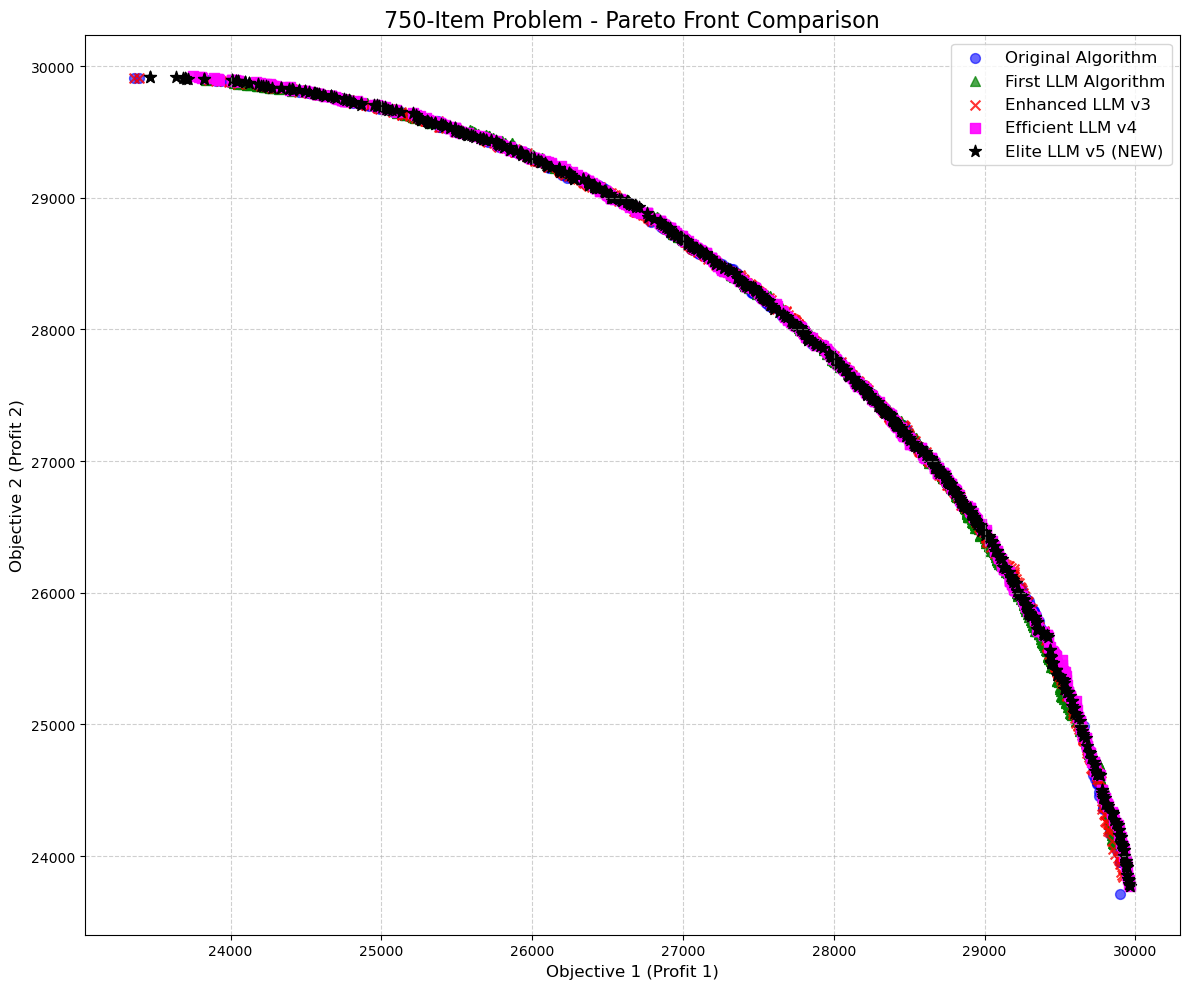


              SUMMARY OF IMPROVEMENTS
250 Items:
  Efficient LLM v4: HV 3.91%
  Elite LLM v5: HV 3.55%

500 Items:
  Enhanced LLM v3: HV 3.22%
  Efficient LLM v4: HV 1.91%
  Elite LLM v5: HV 1.97%

750 Items:
  Elite LLM v5: HV 0.32%

--- AVERAGE HV IMPROVEMENTS ---
  Enhanced LLM v3: 0.46%
  Efficient LLM v4: 1.56%
  Elite LLM v5: 1.94%

Improvement of Elite v5 over Efficient v4:
  Hypervolume: 0.38%


In [4]:
# Results comparison and analysis for the elite refinement implementation (v5)
import matplotlib.pyplot as plt
import numpy as np

def dominates(a, b):
    """Returns True if a dominates b (maximization for both objectives)."""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    """Extract the true Pareto front from a set of points"""
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def calculate_hypervolume(points):
    """Calculate a simplified hypervolume metric for comparison."""
    if not points:
        return 0.0
    
    ref_x = max(p[0] for p in points) * 1.1
    ref_y = max(p[1] for p in points) * 1.1
    
    sorted_points = sorted(points, key=lambda p: p[0])
    
    hv = 0.0
    for i in range(len(sorted_points) - 1):
        x1, y1 = sorted_points[i]
        x2, y2 = sorted_points[i + 1]
        hv += (x2 - x1) * (ref_y - y1)
    
    if sorted_points:
        x_last, y_last = sorted_points[-1]
        hv += (ref_x - x_last) * (ref_y - y_last)
    
    return hv

def load_points_from_file(filename):
    """Safely loads points from a file, handling missing files."""
    points = []
    try:
        with open(filename, "r") as f:
            for line in f:
                line = line.strip()
                if line and not line.startswith("#"): # Ignore log lines
                    try:
                        points.append([float(x) for x in line.split()])
                    except Exception:
                        pass # skip malformed lines
    except FileNotFoundError:
        print(f"Warning: Result file '{filename}' not found. Skipping this dataset.")
        return []
    return points

def compare_all_results_v5(original_file, first_llm_file, enhanced_v3_file, efficient_v4_file, elite_v5_file, title):
    """Compare original, first LLM, enhanced v3, efficient v4, and elite v5 results"""
    
    original_points = load_points_from_file(original_file)
    first_llm_points = load_points_from_file(first_llm_file)
    enhanced_v3_points = load_points_from_file(enhanced_v3_file)
    efficient_v4_points = load_points_from_file(efficient_v4_file)
    elite_v5_points = load_points_from_file(elite_v5_file)

    original_pareto = get_true_pareto_front(original_points)
    first_llm_pareto = get_true_pareto_front(first_llm_points)
    enhanced_v3_pareto = get_true_pareto_front(enhanced_v3_points)
    efficient_v4_pareto = get_true_pareto_front(efficient_v4_points)
    elite_v5_pareto = get_true_pareto_front(elite_v5_points)
    
    original_size = len(original_pareto)
    first_llm_size = len(first_llm_pareto)
    enhanced_v3_size = len(enhanced_v3_pareto)
    efficient_v4_size = len(efficient_v4_pareto)
    elite_v5_size = len(elite_v5_pareto)
    
    first_llm_size_improvement = (first_llm_size - original_size) / original_size * 100 if original_size > 0 else 0
    enhanced_v3_size_improvement = (enhanced_v3_size - original_size) / original_size * 100 if original_size > 0 else 0
    efficient_v4_size_improvement = (efficient_v4_size - original_size) / original_size * 100 if original_size > 0 else 0
    elite_v5_size_improvement = (elite_v5_size - original_size) / original_size * 100 if original_size > 0 else 0
    
    original_hv = calculate_hypervolume(original_pareto)
    first_llm_hv = calculate_hypervolume(first_llm_pareto)
    enhanced_v3_hv = calculate_hypervolume(enhanced_v3_pareto)
    efficient_v4_hv = calculate_hypervolume(efficient_v4_pareto)
    elite_v5_hv = calculate_hypervolume(elite_v5_pareto)
    
    first_llm_hv_improvement = (first_llm_hv - original_hv) / original_hv * 100 if original_hv > 0 else 0
    enhanced_v3_hv_improvement = (enhanced_v3_hv - original_hv) / original_hv * 100 if original_hv > 0 else 0
    efficient_v4_hv_improvement = (efficient_v4_hv - original_hv) / original_hv * 100 if original_hv > 0 else 0
    elite_v5_hv_improvement = (elite_v5_hv - original_hv) / original_hv * 100 if original_hv > 0 else 0
    
    print(f"\n--- {title} ---")
    print(f"  Original Pareto size: {original_size}")
    if first_llm_size > 0: print(f"  First LLM Pareto size: {first_llm_size} ({first_llm_size_improvement:.2f}%)")
    if enhanced_v3_size > 0: print(f"  Enhanced LLM v3 Pareto size: {enhanced_v3_size} ({enhanced_v3_size_improvement:.2f}%)")
    if efficient_v4_size > 0: print(f"  Efficient LLM v4 Pareto size: {efficient_v4_size} ({efficient_v4_size_improvement:.2f}%)")
    if elite_v5_size > 0: print(f"  Elite LLM v5 Pareto size: {elite_v5_size} ({elite_v5_size_improvement:.2f}%)")
    
    print(f"  Original Hypervolume: {original_hv:.2f}")
    if first_llm_hv > 0: print(f"  First LLM Hypervolume: {first_llm_hv:.2f} ({first_llm_hv_improvement:.2f}%)")
    if enhanced_v3_hv > 0: print(f"  Enhanced LLM v3 Hypervolume: {enhanced_v3_hv:.2f} ({enhanced_v3_hv_improvement:.2f}%)")
    if efficient_v4_hv > 0: print(f"  Efficient LLM v4 Hypervolume: {efficient_v4_hv:.2f} ({efficient_v4_hv_improvement:.2f}%)")
    if elite_v5_hv > 0: print(f"  Elite LLM v5 Hypervolume: {elite_v5_hv:.2f} ({elite_v5_hv_improvement:.2f}%)")
    
    plt.figure(figsize=(12, 10))
    
    if original_pareto:
        ox, oy = zip(*original_pareto)
        plt.scatter(ox, oy, color='blue', alpha=0.6, s=50, label="Original Algorithm")
    if first_llm_pareto:
        fx, fy = zip(*first_llm_pareto)
        plt.scatter(fx, fy, color='green', marker='^', s=50, alpha=0.7, label="First LLM Algorithm")
    if enhanced_v3_pareto:
        ex, ey = zip(*enhanced_v3_pareto)
        plt.scatter(ex, ey, color='red', marker='x', s=50, alpha=0.8, label="Enhanced LLM v3")
    if efficient_v4_pareto:
        ex4, ey4 = zip(*efficient_v4_pareto)
        plt.scatter(ex4, ey4, color='magenta', marker='s', s=50, alpha=0.9, label="Efficient LLM v4")
    if elite_v5_pareto:
        ex5, ey5 = zip(*elite_v5_pareto)
        plt.scatter(ex5, ey5, color='black', marker='*', s=80, label="Elite LLM v5 (NEW)")

    plt.xlabel("Objective 1 (Profit 1)", fontsize=12)
    plt.ylabel("Objective 2 (Profit 2)", fontsize=12)
    plt.title(f"{title} - Pareto Front Comparison", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return {
        "original_size": original_size, "first_llm_size": first_llm_size, "enhanced_v3_size": enhanced_v3_size, "efficient_v4_size": efficient_v4_size, "elite_v5_size": elite_v5_size,
        "first_llm_size_improvement": first_llm_size_improvement, "enhanced_v3_size_improvement": enhanced_v3_size_improvement, "efficient_v4_size_improvement": efficient_v4_size_improvement, "elite_v5_size_improvement": elite_v5_size_improvement,
        "original_hv": original_hv, "first_llm_hv": first_llm_hv, "enhanced_v3_hv": enhanced_v3_hv, "efficient_v4_hv": efficient_v4_hv, "elite_v5_hv": elite_v5_hv,
        "first_llm_hv_improvement": first_llm_hv_improvement, "enhanced_v3_hv_improvement": enhanced_v3_hv_improvement, "efficient_v4_hv_improvement": efficient_v4_hv_improvement, "elite_v5_hv_improvement": elite_v5_hv_improvement
    }

# --- MAIN EXECUTION ---
print("Starting comprehensive results analysis for Elite Refinement implementation v5...")

# NOTE: The analysis will now work even if you only have the original and v5 results.
results_250 = compare_all_results_v5(
    "2502_ResultsMD.txt", "2502_Results_LLM_Enhanced.txt", "2502_Results_Enhanced_LLM_v3.txt", "2502_Results_Efficient_LLM_v4.txt", "2502_Results_Elite_Refinement_v5.txt", "250-Item Problem"
)
results_500 = compare_all_results_v5(
    "5002_ResultsMD.txt", "5002_Results_LLM_Enhanced.txt", "5002_Results_Enhanced_LLM_v3.txt", "5002_Results_Efficient_LLM_v4.txt", "5002_Results_Elite_Refinement_v5.txt", "500-Item Problem"
)
results_750 = compare_all_results_v5(
    "7502_ResultsMD.txt", "7502_Results_LLM_Enhanced.txt", "7502_Results_Enhanced_LLM_v3.txt", "7502_Results_Efficient_LLM_v4.txt", "7502_Results_Elite_Refinement_v5.txt", "750-Item Problem"
)

# Summary of improvements
print("\n======================================================")
print("              SUMMARY OF IMPROVEMENTS")
print("======================================================")
print("250 Items:")
if results_250['first_llm_hv_improvement'] > 0: print(f"  First LLM: HV {results_250['first_llm_hv_improvement']:.2f}%")
if results_250['enhanced_v3_hv_improvement'] > 0: print(f"  Enhanced LLM v3: HV {results_250['enhanced_v3_hv_improvement']:.2f}%")
if results_250['efficient_v4_hv_improvement'] > 0: print(f"  Efficient LLM v4: HV {results_250['efficient_v4_hv_improvement']:.2f}%")
if results_250['elite_v5_hv_improvement'] > 0: print(f"  Elite LLM v5: HV {results_250['elite_v5_hv_improvement']:.2f}%")

print("\n500 Items:")
if results_500['first_llm_hv_improvement'] > 0: print(f"  First LLM: HV {results_500['first_llm_hv_improvement']:.2f}%")
if results_500['enhanced_v3_hv_improvement'] > 0: print(f"  Enhanced LLM v3: HV {results_500['enhanced_v3_hv_improvement']:.2f}%")
if results_500['efficient_v4_hv_improvement'] > 0: print(f"  Efficient LLM v4: HV {results_500['efficient_v4_hv_improvement']:.2f}%")
if results_500['elite_v5_hv_improvement'] > 0: print(f"  Elite LLM v5: HV {results_500['elite_v5_hv_improvement']:.2f}%")

print("\n750 Items:")
if results_750['first_llm_hv_improvement'] > 0: print(f"  First LLM: HV {results_750['first_llm_hv_improvement']:.2f}%")
if results_750['enhanced_v3_hv_improvement'] > 0: print(f"  Enhanced LLM v3: HV {results_750['enhanced_v3_hv_improvement']:.2f}%")
if results_750['efficient_v4_hv_improvement'] > 0: print(f"  Efficient LLM v4: HV {results_750['efficient_v4_hv_improvement']:.2f}%")
if results_750['elite_v5_hv_improvement'] > 0: print(f"  Elite LLM v5: HV {results_750['elite_v5_hv_improvement']:.2f}%")

# Calculate averages only for versions that have data
hv_improvements = {
    "v3": [results_250['enhanced_v3_hv_improvement'], results_500['enhanced_v3_hv_improvement'], results_750['enhanced_v3_hv_improvement']],
    "v4": [results_250['efficient_v4_hv_improvement'], results_500['efficient_v4_hv_improvement'], results_750['efficient_v4_hv_improvement']],
    "v5": [results_250['elite_v5_hv_improvement'], results_500['elite_v5_hv_improvement'], results_750['elite_v5_hv_improvement']],
}

print("\n--- AVERAGE HV IMPROVEMENTS ---")
if any(imp > 0 for imp in hv_improvements["v3"]):
    print(f"  Enhanced LLM v3: {sum(hv_improvements['v3']) / 3:.2f}%")
if any(imp > 0 for imp in hv_improvements["v4"]):
    print(f"  Efficient LLM v4: {sum(hv_improvements['v4']) / 3:.2f}%")
if any(imp > 0 for imp in hv_improvements["v5"]):
    print(f"  Elite LLM v5: {sum(hv_improvements['v5']) / 3:.2f}%")

if any(imp > 0 for imp in hv_improvements["v4"]) and any(imp > 0 for imp in hv_improvements["v5"]):
    print("\nImprovement of Elite v5 over Efficient v4:")
    print(f"  Hypervolume: {sum(hv_improvements['v5']) / 3 - sum(hv_improvements['v4']) / 3:.2f}%")
print("======================================================")

In [15]:
# Simple test to see if the module exists and can be imported
try:
    import optimized_moacp_cython
    print("✅ Module imported successfully.")
    print("Functions available:", dir(optimized_moacp_cython))
except ImportError as e:
    print(f"❌ ImportError: {e}")
except Exception as e:
    print(f"❌ Other error: {e}")

✅ Module imported successfully.
Functions available: ['__builtins__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '__test__', 'get_L', 'get_alpha', 'get_kappa', 'np', 'run_optimized_cython_moacp', 'seed', 'set_L', 'set_alpha', 'set_kappa', 'set_smallValue', 'time']


In [10]:
import optimized_moacp_cython as omc
print(dir(omc))

['__builtins__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '__test__', 'get_L', 'get_alpha', 'get_kappa', 'np', 'run_optimized_cython_moacp', 'seed', 'set_L', 'set_alpha', 'set_kappa', 'set_smallValue', 'time']


In [16]:
import optimized_moacp_cython as omc

for fn in [
    "set_alpha", "set_kappa", "set_L", "set_smallValue",
    "set_mutation_rate", "set_local_search_intensity",
    "set_greedy_bias", "set_repair_aggressiveness"
]:
    print(fn, hasattr(omc, fn))

set_alpha True
set_kappa True
set_L True
set_smallValue True
set_mutation_rate False
set_local_search_intensity False
set_greedy_bias False
set_repair_aggressiveness False
